# Import Libraries

In this step, we import the main libraries needed for the project.

- pandas → used to load and work with the dataset  
- numpy → used for numerical operations  
- matplotlib → used to create charts and visualize data  

We also import machine learning tools from scikit-learn:

- train_test_split → splits data into training and testing sets  
- LogisticRegression → a simple classification model  
- RandomForestClassifier → a more advanced model for better predictions  
- classification_report → shows model performance (precision, recall, etc.)  
- confusion_matrix → shows how well the model predicted correctly  

These tools will help us move from data analysis to building a predictive model.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Inspect Raw File

In this step, we open the CSV file and print the first few lines.

We use this to check:
- how the data is separated (comma, tab, etc.)
- if there are any formatting issues
- what the raw data looks like before loading into pandas

This helps us avoid errors when reading the file.

In [46]:
with open(r"C:\Users\Charm\Downloads\product_metric.csv", "r", encoding="utf-8") as f:
    for i in range(10):
        print(repr(f.readline()))

'\ufeff1,Chocolate Sandwich Cookies,61,19,1754,0.647662485746,10.4327251995439\n'
'2,All-Seasons Salt,104,13,87,0.137931034482,10.4827586206897\n'
'3,Robust Golden Unsweetened Oolong Tea,94,7,260,0.780769230769,10.5653846153846\n'
'4,Smart Ones Classic Favorites Mini Rigatoni With Vodka Cream Sauce,38,1,290,0.506896551724,14.6862068965517\n'
'5,Green Chile Anytime Sauce,5,13,14,0.642857142857,12.4285714285714\n'
'6,Dry Nose Oil,11,11,8,0.375000000000,11.125\n'
'7,Pure Coconut Water With Orange,98,7,28,0.428571428571,11.2857142857143\n'
"8,Cut Russet Potatoes Steam N' Mash,116,1,151,0.549668874172,10.0927152317881\n"
'9,Light Strawberry Blueberry Yogurt,120,16,140,0.585714285714,14.1285714285714\n'
'10,Sparkling Orange Juice & Prickly Pear Beverage,115,7,2441,0.534207292093,11.4608766898812\n'


# Load Dataset into Pandas

In this step, we load the CSV file into a pandas DataFrame.

- pd.read_csv() is used to read the file  
- sep="\t" means the data is separated by tabs  
- df.head() shows the first few rows of the dataset  

This helps us confirm that the data was loaded correctly and is structured as expected.

In [47]:
df = pd.read_csv(r"C:\Users\Charm\Downloads\product_metric.csv", sep="\t")
df.head()

,"1,Chocolate Sandwich Cookies,61,19,1754,0.647662485746,10.4327251995439"
0,"2,All-Seasons Salt,104,13,87,0.137931034482,10..."
1,"3,Robust Golden Unsweetened Oolong Tea,94,7,26..."
2,"4,Smart Ones Classic Favorites Mini Rigatoni W..."
3,"5,Green Chile Anytime Sauce,5,13,14,0.64285714..."
4,"6,Dry Nose Oil,11,11,8,0.375000000000,11.125"


# Load Dataset (Alternative Method)

In this step, we load the dataset again using a more flexible parser.

- sep="\t" tells pandas the file is tab-separated  
- engine="python" uses a more tolerant parser for messy files  

This method is useful when the default reader fails due to formatting issues.

We use df.head() to check that the data is loaded correctly.

In [48]:
df = pd.read_csv(
    r"C:\Users\Charm\Downloads\product_metric.csv",
    sep="\t",
    engine="python"
)
df.head()

,"1,Chocolate Sandwich Cookies,61,19,1754,0.647662485746,10.4327251995439"
0,"2,All-Seasons Salt,104,13,87,0.137931034482,10..."
1,"3,Robust Golden Unsweetened Oolong Tea,94,7,26..."
2,"4,Smart Ones Classic Favorites Mini Rigatoni W..."
3,"5,Green Chile Anytime Sauce,5,13,14,0.64285714..."
4,"6,Dry Nose Oil,11,11,8,0.375000000000,11.125"


In [49]:
df = pd.read_csv(r"C:\Users\Charm\Downloads\product_metric.csv", sep="|")

In [50]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
df.describe()

(49645, 1)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49645 entries, 0 to 49644
Data columns (total 1 columns):
 #   Column                                                                   Non-Null Count  Dtype 
---  ------                                                                   --------------  ----- 
 0   1,Chocolate Sandwich Cookies,61,19,1754,0.647662485746,10.4327251995439  49645 non-null  object
dtypes: object(1)
memory usage: 388.0+ KB
None
1,Chocolate Sandwich Cookies,61,19,1754,0.647662485746,10.4327251995439    0
dtype: int64


,"1,Chocolate Sandwich Cookies,61,19,1754,0.647662485746,10.4327251995439"
count,49645
unique,49645
top,"2,All-Seasons Salt,104,13,87,0.137931034482,10..."
freq,1


# Load and Clean Dataset

In this step, we load the dataset and fix its structure.

- sep="," tells pandas the data is separated by commas  
- header=None means the file does not have column names  

Since there are no headers, we manually assign column names:
- product_id → unique product identifier  
- product_name → name of the product  
- aisle_id → aisle category  
- department_id → department category  
- total_units → number of times the product was sold  
- reorder_rate → how often the product is reordered  
- avg_days_between_orders → average time between purchases  

We use df.head() to confirm everything looks correct.

In [51]:
df = pd.read_csv(
    r"C:\Users\Charm\Downloads\product_metric.csv",
    sep=",",
    header=None
)

df.columns = [
    "product_id",
    "product_name",
    "aisle_id",
    "department_id",
    "total_units",
    "reorder_rate",
    "avg_days_between_orders"
]

df.head()

,product_id,product_name,aisle_id,department_id,total_units,reorder_rate,avg_days_between_orders
0,1,Chocolate Sandwich Cookies,61,19,1754,0.647662,10.432725
1,2,All-Seasons Salt,104,13,87,0.137931,10.482759
2,3,Robust Golden Unsweetened Oolong Tea,94,7,260,0.780769,10.565385
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,290,0.506897,14.686207
4,5,Green Chile Anytime Sauce,5,13,14,0.642857,12.428571


# Explore Dataset (Basic Checks)

In this step, we explore the dataset to understand its structure and quality.

- df.shape → shows the number of rows and columns  
- df.info() → shows data types and missing values  
- df.isnull().sum() → counts missing values in each column  
- df.describe() → gives summary statistics (mean, min, max, etc.)  

This helps us:
- confirm the dataset loaded correctly  
- check for missing data  
- understand the distribution of key features  

These checks are important before building any model.

In [52]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
df.describe()

(49646, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49646 entries, 0 to 49645
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product_id               49646 non-null  int64  
 1   product_name             49646 non-null  object 
 2   aisle_id                 49646 non-null  int64  
 3   department_id            49646 non-null  int64  
 4   total_units              49646 non-null  int64  
 5   reorder_rate             49646 non-null  float64
 6   avg_days_between_orders  49646 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 2.7+ MB
None
product_id                 0
product_name               0
aisle_id                   0
department_id              0
total_units                0
reorder_rate               0
avg_days_between_orders    0
dtype: int64


,product_id,aisle_id,department_id,total_units,reorder_rate,avg_days_between_orders
count,49646.000000,49646.000000,49646.000000,49646.000000,49646.000000,49646.000000
mean,24841.300608,67.770797,11.727350,611.457539,0.395891,11.564944
std,14343.345263,38.315963,5.850498,4508.234895,0.222129,2.761655
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,12422.250000,35.000000,7.000000,16.000000,0.230769,10.019540
50%,24836.500000,69.000000,13.000000,55.000000,0.411765,11.388826
75%,37261.750000,100.000000,17.000000,242.000000,0.571429,12.918397
max,49688.000000,134.000000,21.000000,443031.000000,1.000000,30.000000


# Visualize Feature Distributions

In this step, we create histograms to understand how the data is distributed.

We look at three key features:

- total_units → how many times each product was sold  
- reorder_rate → how often products are reordered  
- avg_days_between_orders → time between purchases  

Each histogram shows:
- how values are spread out  
- whether most products are low or high in each metric  

This helps us:
- understand patterns in the data  
- detect skewness (many low values vs few high values)  
- prepare for feature engineering and modeling  

Visualizing data is important before building any model.

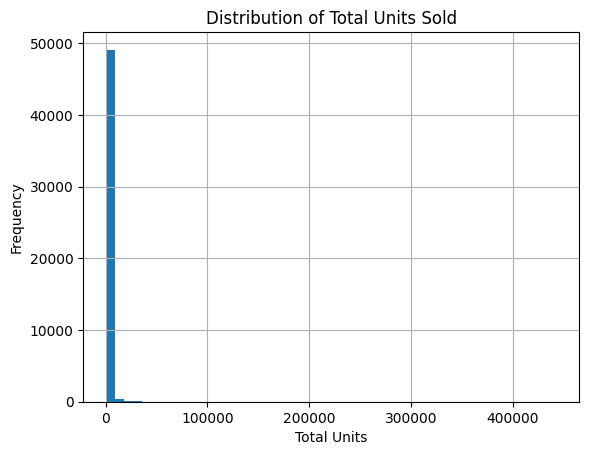

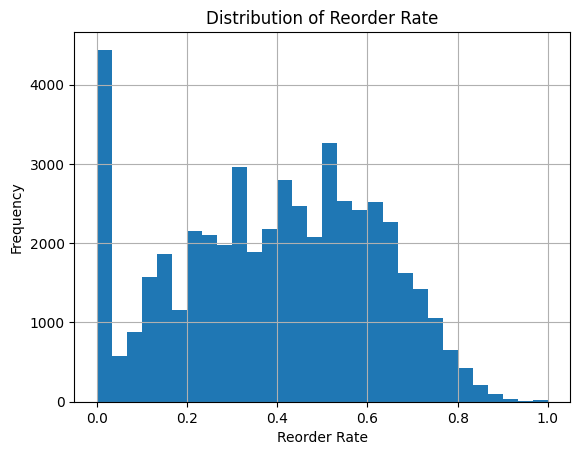

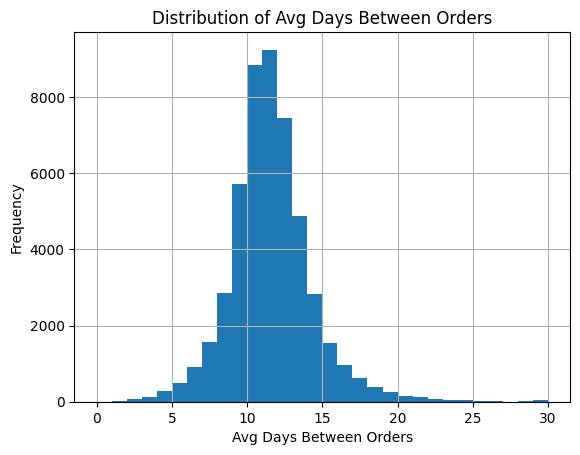

In [53]:
df["total_units"].hist(bins=50)
plt.title("Distribution of Total Units Sold")
plt.xlabel("Total Units")
plt.ylabel("Frequency")
plt.show()

df["reorder_rate"].hist(bins=30)
plt.title("Distribution of Reorder Rate")
plt.xlabel("Reorder Rate")
plt.ylabel("Frequency")
plt.show()

df["avg_days_between_orders"].hist(bins=30)
plt.title("Distribution of Avg Days Between Orders")
plt.xlabel("Avg Days Between Orders")
plt.ylabel("Frequency")
plt.show()

# Create Stockout Risk Label

In this step, we create a new column called `at_risk`.

Since we do not have real stockout data, we create a **proxy label** based on product behavior.

We define a product as "at risk" if it meets all three conditions:

- high demand → total_units is in the top 25%  
- high loyalty → reorder_rate is in the top 25%  
- longer purchase cycle → avg_days_between_orders is in the top 25%  

We use `.quantile(0.75)` to get the cutoff values for the top 25%.

If a product meets all conditions:
- at_risk = 1  

Otherwise:
- at_risk = 0  

Finally, we use `value_counts()` to see how many products are labeled as at risk vs not at risk.

This step prepares the target variable for our classification model.

In [54]:
volume_cutoff = df["total_units"].quantile(0.75)
reorder_cutoff = df["reorder_rate"].quantile(0.75)
days_cutoff = df["avg_days_between_orders"].quantile(0.75)

df["at_risk"] = (
    (df["total_units"] >= volume_cutoff) &
    (df["reorder_rate"] >= reorder_cutoff) &
    (df["avg_days_between_orders"] >= days_cutoff)
).astype(int)

df["at_risk"].value_counts()

at_risk
0    49156
1      490
Name: count, dtype: int64

# Inspect High-Risk Products

In this step, we look at the products labeled as `at_risk = 1`.

We:
- filter only high-risk products  
- sort them by:
  - highest reorder_rate  
  - then highest total_units  

This helps us identify:
- the most important high-risk products  
- products with strong demand and strong customer loyalty  

We use `.head(20)` to display the top 20 products.

This step gives us a clear view of which products are most sensitive to stockouts.

In [55]:
df[df["at_risk"] == 1].sort_values(
    ["reorder_rate", "total_units"], ascending=[False, False]
).head(20)

,product_id,product_name,aisle_id,department_id,total_units,reorder_rate,avg_days_between_orders,at_risk
20928,20940,Organic Low Fat Milk,84,16,7828,0.899336,13.620976,1
8563,8571,Baby Cucumbers,32,4,13338,0.845854,13.287374,1
24427,24441,2% Reduced Fat Milk With Vitamin A&D,84,16,478,0.843096,13.169456,1
17912,17924,Seltzer Water,115,7,1735,0.840346,16.133141,1
27705,27726,Lemon Seltzer Water,77,7,418,0.839713,12.952153,1
1728,1729,2% Lactose Free Milk,84,16,1644,0.824209,13.558394,1
17195,17207,Non Fat Greek Yogurt,120,16,3783,0.818134,13.275707,1
31119,31141,Old Tyme 100% Whole Grain White Wheat Sliced B...,112,3,326,0.812883,13.628834,1
11874,11885,"Sparkling Water, Bottles",115,7,1440,0.806944,13.437500,1
12629,12640,Sport Bottle with Flip Cap Natural Spring Water,115,7,452,0.803097,15.657080,1


# Train Logistic Regression Model

In this step, we build our first classification model.

### 1. Select features
We use:
- total_units  
- reorder_rate  
- avg_days_between_orders  

These features help describe product demand and behavior.

### 2. Define target
- at_risk → what we want to predict (0 or 1)

### 3. Split the data
We split the dataset into:
- training set (80%) → used to train the model  
- testing set (20%) → used to evaluate the model  

We use `stratify=y` to keep the same class distribution in both sets.

### 4. Train the model
We use Logistic Regression:
- simple  
- easy to interpret  

### 5. Make predictions
We predict on the test set.

### 6. Evaluate performance
`classification_report` shows:
- precision → how accurate the predictions are  
- recall → how well the model finds at-risk products  
- f1-score → balance between precision and recall  

This gives us a baseline model for stockout risk prediction.

In [56]:
features = ["total_units", "reorder_rate", "avg_days_between_orders"]
X = df[features]
y = df["at_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [57]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

print(classification_report(y_test, lr_preds))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9832
           1       0.00      0.00      0.00        98

    accuracy                           0.99      9930
   macro avg       0.50      0.50      0.50      9930
weighted avg       0.98      0.99      0.98      9930



# Model Evaluation (Logistic Regression)

The model shows very high accuracy (~99%), but this is misleading.

The recall and precision for the "at_risk" class (1) are both 0.

This means:
- the model is not detecting any high-risk products
- it is predicting all products as not at risk

This happens because of class imbalance:
- most products are labeled 0 (not at risk)
- very few products are labeled 1 (at risk)

As a result, the model learns to always predict the majority class.

This shows that accuracy alone is not a good metric for imbalanced datasets.

In [58]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

print(classification_report(y_test, lr_preds))

              precision    recall  f1-score   support

           0       1.00      0.87      0.93      9832
           1       0.07      0.99      0.13        98

    accuracy                           0.87      9930
   macro avg       0.53      0.93      0.53      9930
weighted avg       0.99      0.87      0.92      9930



# Model Improvement (Handling Imbalance)

After applying class_weight="balanced", the model improved significantly.

- Recall for at_risk (class 1) increased to ~0.99  
- This means the model is able to detect almost all high-risk products  

However:
- Precision is low (~0.07), meaning many products are incorrectly flagged as at risk  

This shows a trade-off:
- High recall → fewer missed risky products  
- Low precision → more false positives  

From a business perspective, this is acceptable because:
it is better to flag more products than to miss critical stockout risks.

# Confusion Matrix (Logistic Regression)

In this step, we visualize the model’s predictions using a confusion matrix.

The confusion matrix shows:
- True Positives → correctly predicted at-risk products  
- True Negatives → correctly predicted safe products  
- False Positives → products predicted as at risk but are not  
- False Negatives → products that are at risk but were missed  

This helps us understand:
- how well the model is performing  
- where it is making mistakes  

In this case, we expect:
- very few false negatives (good recall)  
- more false positives (lower precision)  

This confirms the trade-off between catching all risky products and making extra predictions.

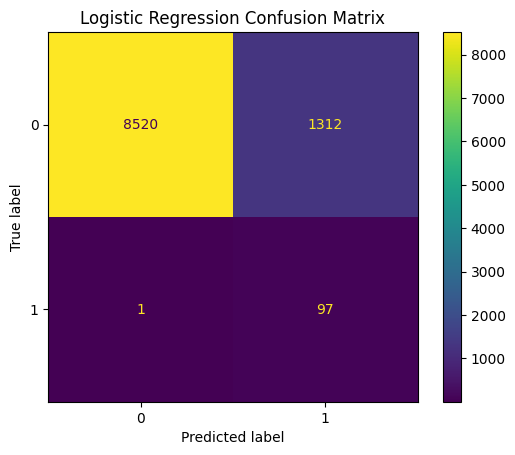

In [59]:
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Train Random Forest Model

In this step, we train a Random Forest model to compare with Logistic Regression.

Random Forest is:
- a more advanced model  
- able to capture non-linear patterns in the data  
- often performs better on complex datasets  

### Model setup
- n_estimators=200 → number of trees in the forest  
- max_depth=5 → limits tree depth to avoid overfitting  
- random_state=42 → ensures reproducible results  

### Steps
- train the model on the training data  
- make predictions on the test set  
- evaluate using classification_report  

This allows us to compare performance between models and choose the best one for detecting at-risk products.

In [43]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9832
           1       1.00      0.99      0.99        98

    accuracy                           1.00      9930
   macro avg       1.00      0.99      1.00      9930
weighted avg       1.00      1.00      1.00      9930



# Model Evaluation (Random Forest)

The Random Forest model shows near-perfect performance, with almost 100% accuracy.

However, this result is misleading.

The target variable (at_risk) was created using the same features used for training:
- total_units  
- reorder_rate  
- avg_days_between_orders  

This causes data leakage, where the model is effectively learning the rule used to create the label.

As a result:
- the model appears perfect  
- but it is not truly predictive  

This highlights an important concept in data science:
models should not be trained on features used to directly construct the target variable.

avg_days_between_orders    0.432689
reorder_rate               0.290064
total_units                0.277246
dtype: float64


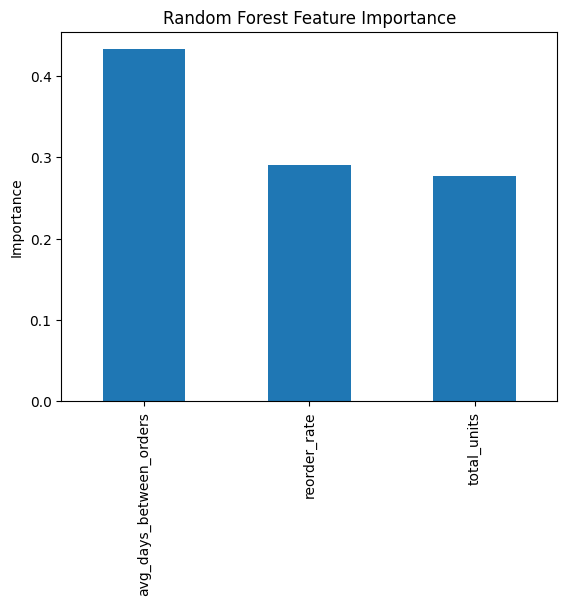

In [60]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

importances.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.show()

# Feature Importance Analysis

The Random Forest model shows that avg_days_between_orders is the most important feature.

This means:
- timing of purchases has the strongest impact on risk  
- products with longer or irregular purchase cycles are harder to manage  

Reorder rate and total units are also important, but less than timing.

This suggests that:
customer behavior patterns are more important than simple demand volume when identifying operational risk.

# Rank Products by Risk Probability

In this step, we use the trained Random Forest model to assign a risk score to each product.

- predict_proba() gives the probability of a product being at risk  
- [:, 1] selects the probability for class 1 (at risk)  

We store this as a new column:
- risk_probability → how likely each product is to be at risk  

Then we:
- sort products from highest to lowest risk  
- select key columns for interpretation  
- display the top 20 highest-risk products  

This step turns the model into a practical tool:
instead of just classifying products, we rank them by risk level.

This can help prioritize which products need closer monitoring in inventory management.

In [61]:
df["risk_probability"] = rf.predict_proba(X)[:, 1]

top_risk = df.sort_values("risk_probability", ascending=False)[
    ["product_name", "total_units", "reorder_rate", "avg_days_between_orders", "risk_probability"]
].head(20)

top_risk

,product_name,total_units,reorder_rate,avg_days_between_orders,risk_probability
5778,Grade A Large White Eggs,11386,0.695328,13.058844,0.798881
40301,"Cage Free Brown Eggs-Large, Grade A",11261,0.679513,13.525442,0.793937
21560,Roasted Pine Nut Hummus,10399,0.665833,13.106549,0.793431
20928,Organic Low Fat Milk,7828,0.899336,13.620976,0.785688
35310,Naked Green Machine Boosted Juice Smoothie,5451,0.629793,13.168593,0.781709
4146,Frozen Organic Blueberries,5881,0.645638,13.082979,0.780688
14985,Ruby Red Grapefruit,2615,0.661950,13.609560,0.775015
23327,Large Grade AA Eggs,6140,0.670195,14.160586,0.773259
33325,Light Multi-Grain English Muffins,4353,0.626465,13.025729,0.773247
33122,Organic Crimini Mushrooms,3640,0.678846,13.232692,0.772849


# Top High-Risk Products (Interpretation)

This table shows the top products ranked by risk_probability.

These products have:
- moderate to high demand  
- strong reorder behavior  
- longer purchase cycles (~13–14 days)  

Key patterns:

- Many items are staples (eggs, milk, bread, vegetables)  
- Several are breakfast or daily-use products  
- Some are health or fresh items (asparagus, blueberries, juice)  

This means:
customers rely on these products, but do not purchase them very frequently.

As a result:
- demand is consistent but spaced out  
- inventory planning becomes more difficult  

Products like eggs and milk appear multiple times, showing that even small variations (organic, cage-free, etc.) matter to customers.

This suggests:
limited substitution — customers may not switch easily if a product is out of stock.

# Final Business Insight

The analysis shows that stockout risk is driven more by customer behavior than raw demand.

Products with:
- strong customer loyalty  
- and longer purchase intervals  

are more sensitive to stockouts.

This means:
warehouse planning should focus not only on how much is sold, but also on how often customers return to buy it.

Tracking purchase timing is critical for preventing stockouts and maintaining customer satisfaction.